In [ ]:
import pandas as pd

# Load preprocessed Random Forest data
X_train_rf = pd.read_csv("/content/X_train_preprocessed.csv")
X_test_rf  = pd.read_csv("/content/X_test_preprocessed.csv")

# Load targets
y_train = pd.read_csv("/content/y_train.csv").squeeze("columns")
y_test  = pd.read_csv("/content/y_test.csv").squeeze("columns")

print("Files loaded successfully.")

print("\nX_train_rf:", X_train_rf.shape)
print("X_test_rf :", X_test_rf.shape)
print("y_train   :", y_train.shape)
print("y_test    :", y_test.shape)

Files loaded successfully.

X_train_rf: (95512, 20)
X_test_rf : (23878, 20)
y_train   : (95512,)
y_test    : (23878,)


In [ ]:
import numpy as np

print("\nMissing values:")
print("X_train:", X_train_rf.isnull().sum().sum())
print("X_test :", X_test_rf.isnull().sum().sum())

print("\nNon-numeric columns:")
print(X_train_rf.select_dtypes(exclude=np.number).columns.tolist())

print("\nSame train/test columns:")
print(list(X_train_rf.columns) == list(X_test_rf.columns))

print("\nTarget values:")
print("Train:", sorted(y_train.unique()))
print("Test :", sorted(y_test.unique()))

print("\nTrain target distribution:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTest target distribution:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))


Missing values:
X_train: 0
X_test : 0

Non-numeric columns:
[]

Same train/test columns:
True

Target values:
Train: [np.int64(0), np.int64(1)]
Test : [np.int64(0), np.int64(1)]

Train target distribution:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

Test target distribution:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_rf, y_train)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [ ]:
# ============================================================
# RANDOM FOREST - STEP 4
# CREATE BASELINE MODEL
# ============================================================

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print(rf_baseline)

RandomForestClassifier(n_jobs=-1, random_state=42)


In [ ]:
# ============================================================
# RANDOM FOREST - STEP 5
# TRAIN BASELINE MODEL
# ============================================================

rf_baseline.fit(
    X_train_rf,
    y_train
)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [ ]:
# ============================================================
# RANDOM FOREST - STEP 6
# TEST PREDICTIONS
# ============================================================

y_pred_baseline = rf_baseline.predict(
    X_test_rf
)

print("Predictions completed.")

print("\nFirst 20 predictions:")
print(y_pred_baseline[:20])

Predictions completed.

First 20 predictions:
[0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0 1]


In [ ]:
# ============================================================
# RANDOM FOREST - STEP 7
# PREDICT PROBABILITIES
# ============================================================

y_prob_baseline = rf_baseline.predict_proba(
    X_test_rf
)[:, 1]

print("First 10 cancellation probabilities:")

for probability in y_prob_baseline[:10]:
    print(f"{probability:.4f}")

First 10 cancellation probabilities:
0.1547
0.0300
0.9500
0.0300
0.0000
1.0000
1.0000
0.7000
0.0300
0.0000


In [ ]:
# ============================================================
# RANDOM FOREST - STEP 8
# BASELINE EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline
)

baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_baseline
)

baseline_pr_auc = average_precision_score(
    y_test,
    y_prob_baseline
)

print("=" * 60)
print("BASELINE RANDOM FOREST RESULTS")
print("=" * 60)

print(
    f"Accuracy  : {baseline_accuracy:.4f}"
)

print(
    f"Precision : {baseline_precision:.4f}"
)

print(
    f"Recall    : {baseline_recall:.4f}"
)

print(
    f"F1 Score  : {baseline_f1:.4f}"
)

print(
    f"ROC-AUC   : {baseline_roc_auc:.4f}"
)

print(
    f"PR-AUC    : {baseline_pr_auc:.4f}"
)

BASELINE RANDOM FOREST RESULTS
Accuracy  : 0.8925
Precision : 0.8790
Recall    : 0.8230
F1 Score  : 0.8501
ROC-AUC   : 0.9584
PR-AUC    : 0.9401


In [ ]:
# ============================================================
# RANDOM FOREST - STEP 9
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ]
    )
)

               precision    recall  f1-score   support

Not Cancelled       0.90      0.93      0.92     15033
    Cancelled       0.88      0.82      0.85      8845

     accuracy                           0.89     23878
    macro avg       0.89      0.88      0.88     23878
 weighted avg       0.89      0.89      0.89     23878



In [ ]:
# ============================================================
# RANDOM FOREST - STEP 10
# CONFUSION MATRIX
# ============================================================

cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

print("Confusion Matrix:")
print(cm_baseline)

TN, FP, FN, TP = cm_baseline.ravel()

print("\nTrue Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

Confusion Matrix:
[[14031  1002]
 [ 1566  7279]]

True Negatives : 14031
False Positives: 1002
False Negatives: 1566
True Positives : 7279


In [ ]:
# ============================================================
# RANDOM FOREST - STEP 11
# BASELINE RESULT TABLE
# ============================================================

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Baseline Random Forest": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc,
        baseline_pr_auc
    ]
})

baseline_results[
    "Baseline Random Forest"
] = baseline_results[
    "Baseline Random Forest"
].round(4)

display(baseline_results)

,Metric,Baseline Random Forest
0,Accuracy,0.8925
1,Precision,0.8790
2,Recall,0.8230
3,F1 Score,0.8501
4,ROC-AUC,0.9584
5,PR-AUC,0.9401


In [ ]:
# ============================================================
# RANDOM FOREST
# CHECK TRAINING VS TEST PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. PREDICT TRAINING DATA
# ------------------------------------------------------------

y_train_pred = rf_baseline.predict(X_train_rf)

# ------------------------------------------------------------
# 2. TRAINING METRICS
# ------------------------------------------------------------

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

train_precision = precision_score(
    y_train,
    y_train_pred
)

train_recall = recall_score(
    y_train,
    y_train_pred
)

train_f1 = f1_score(
    y_train,
    y_train_pred
)

# ------------------------------------------------------------
# 3. TEST METRICS
# Already calculated previously
# ------------------------------------------------------------

test_accuracy = baseline_accuracy
test_precision = baseline_precision
test_recall = baseline_recall
test_f1 = baseline_f1


# ------------------------------------------------------------
# 4. DISPLAY COMPARISON
# ------------------------------------------------------------

print("=" * 65)
print("TRAINING VS TEST PERFORMANCE")
print("=" * 65)

print(
    f"Accuracy  - Train: {train_accuracy:.4f} | "
    f"Test: {test_accuracy:.4f} | "
    f"Gap: {train_accuracy - test_accuracy:.4f}"
)

print(
    f"Precision - Train: {train_precision:.4f} | "
    f"Test: {test_precision:.4f} | "
    f"Gap: {train_precision - test_precision:.4f}"
)

print(
    f"Recall    - Train: {train_recall:.4f} | "
    f"Test: {test_recall:.4f} | "
    f"Gap: {train_recall - test_recall:.4f}"
)

print(
    f"F1 Score  - Train: {train_f1:.4f} | "
    f"Test: {test_f1:.4f} | "
    f"Gap: {train_f1 - test_f1:.4f}"
)

TRAINING VS TEST PERFORMANCE
Accuracy  - Train: 0.9955 | Test: 0.8925 | Gap: 0.1030
Precision - Train: 0.9953 | Test: 0.8790 | Gap: 0.1163
Recall    - Train: 0.9925 | Test: 0.8230 | Gap: 0.1696
F1 Score  - Train: 0.9939 | Test: 0.8501 | Gap: 0.1438


In [ ]:
# ============================================================
# RANDOM FOREST
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

# Create 5 stratified folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics to evaluate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Perform cross-validation using TRAINING DATA ONLY
cv_results = cross_validate(
    rf_baseline,
    X_train_rf,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("=" * 65)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 65)

for metric in scoring.keys():

    scores = cv_results["test_" + metric]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

5-FOLD STRATIFIED CROSS-VALIDATION
ACCURACY  : 0.8896 +/- 0.0016
PRECISION : 0.8737 +/- 0.0032
RECALL    : 0.8205 +/- 0.0031
F1        : 0.8463 +/- 0.0023
ROC_AUC   : 0.9574 +/- 0.0016


In [ ]:
# ============================================================
# SHOW EACH FOLD RESULT
# ============================================================

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],

    "Accuracy":
        cv_results["test_accuracy"],

    "Precision":
        cv_results["test_precision"],

    "Recall":
        cv_results["test_recall"],

    "F1":
        cv_results["test_f1"],

    "ROC-AUC":
        cv_results["test_roc_auc"]
})

display(
    cv_table.round(4)
)

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,0.8913,0.8768,0.8219,0.8485,0.9583
1,2,0.8865,0.8688,0.8168,0.8420,0.9546
2,3,0.8897,0.8766,0.8174,0.8460,0.9569
3,4,0.8903,0.8750,0.8212,0.8473,0.9593
4,5,0.8901,0.8712,0.8252,0.8476,0.9579


In [ ]:

# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# RANDOMIZED SEARCH
# ============================================================

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.ensemble import RandomForestClassifier


# Base RF for tuning
rf_tune = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)


# Hyperparameter search space
param_dist = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        10,
        15,
        20,
        25
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2"
    ],

    "class_weight": [
        None,
        "balanced"
    ]
}


# Stratified CV for tuning
cv_tune = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


random_search = RandomizedSearchCV(

    estimator=rf_tune,

    param_distributions=param_dist,

    # Try 8 random combinations
    n_iter=8,

    # Optimize F1
    scoring="f1",

    cv=cv_tune,

    random_state=42,

    n_jobs=-1,

    verbose=2
)

print("RandomizedSearchCV created.")

RandomizedSearchCV created.


In [ ]:
# ============================================================
# RUN RANDOMIZED SEARCH
# ============================================================

random_search.fit(
    X_train_rf,
    y_train
)

print("\nTUNING COMPLETE")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



TUNING COMPLETE


In [ ]:
# ============================================================
# BEST HYPERPARAMETERS
# ============================================================

print("=" * 60)
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 60)

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    "\nBest CV F1:",
    round(random_search.best_score_, 4)
)

BEST RANDOM FOREST PARAMETERS
n_estimators: 300
min_samples_split: 5
min_samples_leaf: 2
max_features: sqrt
max_depth: 25
class_weight: balanced

Best CV F1: 0.842


In [ ]:
# ============================================================
# GET BEST TUNED MODEL
# ============================================================

rf_tuned = random_search.best_estimator_

print("\nTuned Random Forest:")
print(rf_tuned)


Tuned Random Forest:
RandomForestClassifier(class_weight='balanced', max_depth=25,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=1, random_state=42)


In [ ]:
# ============================================================
# TUNED RANDOM FOREST - TEST PREDICTIONS
# ============================================================

y_pred_tuned = rf_tuned.predict(X_test_rf)

y_prob_tuned = rf_tuned.predict_proba(
    X_test_rf
)[:, 1]

print("Tuned Random Forest predictions completed.")

Tuned Random Forest predictions completed.


In [ ]:
# ============================================================
# TUNED RANDOM FOREST - EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

tuned_accuracy = accuracy_score(
    y_test, y_pred_tuned
)

tuned_precision = precision_score(
    y_test, y_pred_tuned
)

tuned_recall = recall_score(
    y_test, y_pred_tuned
)

tuned_f1 = f1_score(
    y_test, y_pred_tuned
)

tuned_roc_auc = roc_auc_score(
    y_test, y_prob_tuned
)

tuned_pr_auc = average_precision_score(
    y_test, y_prob_tuned
)

print("=" * 60)
print("TUNED RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1 Score  : {tuned_f1:.4f}")
print(f"ROC-AUC   : {tuned_roc_auc:.4f}")
print(f"PR-AUC    : {tuned_pr_auc:.4f}")

TUNED RANDOM FOREST RESULTS
Accuracy  : 0.8877
Precision : 0.8507
Recall    : 0.8451
F1 Score  : 0.8479
ROC-AUC   : 0.9578
PR-AUC    : 0.9385


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ]
    )
)

               precision    recall  f1-score   support

Not Cancelled       0.91      0.91      0.91     15033
    Cancelled       0.85      0.85      0.85      8845

     accuracy                           0.89     23878
    macro avg       0.88      0.88      0.88     23878
 weighted avg       0.89      0.89      0.89     23878



In [ ]:
# ============================================================
# BASELINE VS TUNED
# ============================================================

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc,
        baseline_pr_auc
    ],

    "Tuned": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_roc_auc,
        tuned_pr_auc
    ]
})

comparison["Difference"] = (
    comparison["Tuned"]
    -
    comparison["Baseline"]
)

display(
    comparison.round(4)
)

,Metric,Baseline,Tuned,Difference
0,Accuracy,0.8925,0.8877,-0.0048
1,Precision,0.8790,0.8507,-0.0283
2,Recall,0.8230,0.8451,0.0222
3,F1 Score,0.8501,0.8479,-0.0022
4,ROC-AUC,0.9584,0.9578,-0.0006
5,PR-AUC,0.9401,0.9385,-0.0016


In [ ]:
# ============================================================
# TUNED RANDOM FOREST
# TRAINING VS TEST PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. PREDICT TRAINING DATA
# ------------------------------------------------------------

y_train_pred_tuned = rf_tuned.predict(
    X_train_rf
)

# ------------------------------------------------------------
# 2. TRAINING METRICS
# ------------------------------------------------------------

tuned_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_tuned
)

tuned_train_precision = precision_score(
    y_train,
    y_train_pred_tuned
)

tuned_train_recall = recall_score(
    y_train,
    y_train_pred_tuned
)

tuned_train_f1 = f1_score(
    y_train,
    y_train_pred_tuned
)

# ------------------------------------------------------------
# 3. DISPLAY TRAIN VS TEST
# ------------------------------------------------------------

print("=" * 70)
print("TUNED RANDOM FOREST - TRAINING VS TEST")
print("=" * 70)

print(
    f"Accuracy  - Train: {tuned_train_accuracy:.4f} | "
    f"Test: {tuned_accuracy:.4f} | "
    f"Gap: {tuned_train_accuracy - tuned_accuracy:.4f}"
)

print(
    f"Precision - Train: {tuned_train_precision:.4f} | "
    f"Test: {tuned_precision:.4f} | "
    f"Gap: {tuned_train_precision - tuned_precision:.4f}"
)

print(
    f"Recall    - Train: {tuned_train_recall:.4f} | "
    f"Test: {tuned_recall:.4f} | "
    f"Gap: {tuned_train_recall - tuned_recall:.4f}"
)

print(
    f"F1 Score  - Train: {tuned_train_f1:.4f} | "
    f"Test: {tuned_f1:.4f} | "
    f"Gap: {tuned_train_f1 - tuned_f1:.4f}"
)

TUNED RANDOM FOREST - TRAINING VS TEST
Accuracy  - Train: 0.9569 | Test: 0.8877 | Gap: 0.0692
Precision - Train: 0.9294 | Test: 0.8507 | Gap: 0.0787
Recall    - Train: 0.9562 | Test: 0.8451 | Gap: 0.1111
F1 Score  - Train: 0.9426 | Test: 0.8479 | Gap: 0.0947


In [ ]:
# ============================================================
# BASELINE VS TUNED - OVERFITTING GAP
# ============================================================

overfitting_comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline Train": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ],

    "Baseline Test": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    "Tuned Train": [
        tuned_train_accuracy,
        tuned_train_precision,
        tuned_train_recall,
        tuned_train_f1
    ],

    "Tuned Test": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

overfitting_comparison["Baseline Gap"] = (
    overfitting_comparison["Baseline Train"]
    -
    overfitting_comparison["Baseline Test"]
)

overfitting_comparison["Tuned Gap"] = (
    overfitting_comparison["Tuned Train"]
    -
    overfitting_comparison["Tuned Test"]
)

display(
    overfitting_comparison.round(4)
)

,Metric,Baseline Train,Baseline Test,Tuned Train,Tuned Test,Baseline Gap,Tuned Gap
0,Accuracy,0.9955,0.8925,0.9569,0.8877,0.1030,0.0692
1,Precision,0.9953,0.8790,0.9294,0.8507,0.1163,0.0787
2,Recall,0.9925,0.8230,0.9562,0.8451,0.1696,0.1111
3,F1 Score,0.9939,0.8501,0.9426,0.8479,0.1438,0.0947


In [ ]:
# ============================================================
# RANDOM FOREST
# TUNED MODEL FEATURE IMPORTANCE
# ============================================================

feature_importance_tuned = pd.DataFrame({

    "Feature":
        X_train_rf.columns,

    "Importance":
        rf_tuned.feature_importances_
})

feature_importance_tuned = (
    feature_importance_tuned
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("TUNED RANDOM FOREST - FEATURE IMPORTANCE")
print("=" * 70)

display(
    feature_importance_tuned.head(20)
)

TUNED RANDOM FOREST - FEATURE IMPORTANCE


,Feature,Importance
0,country_freq,0.136034
1,lead_time,0.127606
2,agent_freq,0.090847
3,deposit_type_Non Refund,0.088484
4,deposit_type_No Deposit,0.073979
5,adr,0.066855
6,total_of_special_requests,0.063364
7,arrival_date_week_number,0.050537
8,arrival_date_day_of_month,0.043268
9,required_car_parking_spaces,0.037437


In [ ]:
# Add percentage importance
feature_importance_tuned[
    "Importance_Percentage"
] = (
    feature_importance_tuned["Importance"]
    * 100
)

display(
    feature_importance_tuned.head(20)
)

,Feature,Importance,Importance_Percentage
0,country_freq,0.136034,13.603435
1,lead_time,0.127606,12.760556
2,agent_freq,0.090847,9.084721
3,deposit_type_Non Refund,0.088484,8.848443
4,deposit_type_No Deposit,0.073979,7.397888
5,adr,0.066855,6.685518
6,total_of_special_requests,0.063364,6.336403
7,arrival_date_week_number,0.050537,5.053682
8,arrival_date_day_of_month,0.043268,4.326840
9,required_car_parking_spaces,0.037437,3.743683


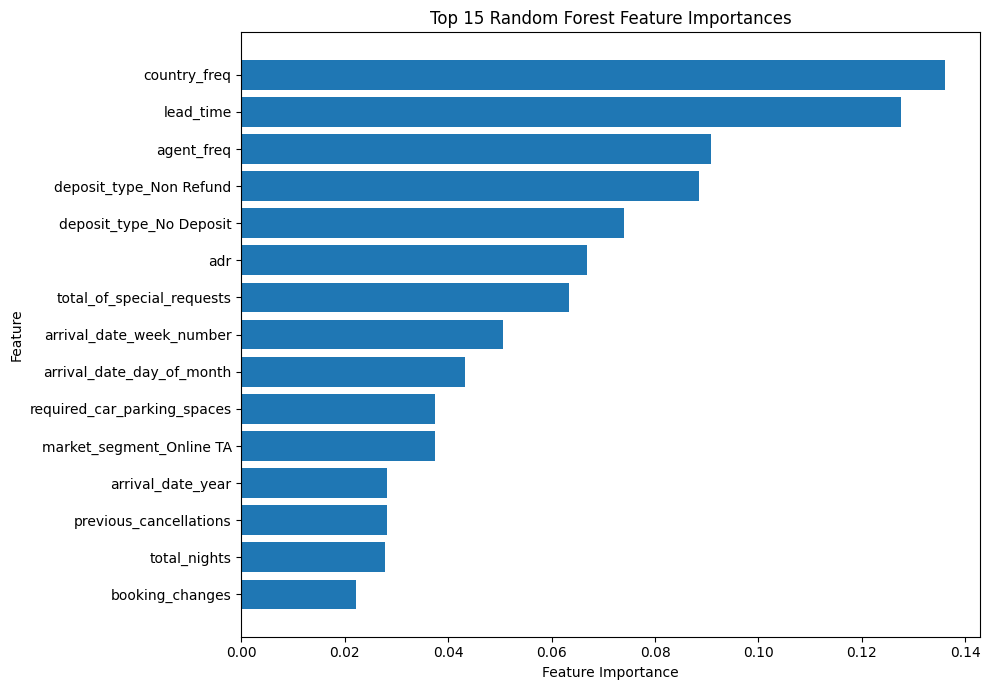

In [ ]:
# ============================================================
# FEATURE IMPORTANCE GRAPH
# ============================================================

import matplotlib.pyplot as plt

top_features_plot = (
    feature_importance_tuned
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_plot["Feature"],
    top_features_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(
    rf_tuned,
    "random_forest_tuned.pkl"
)

print("Tuned Random Forest saved successfully.")

Tuned Random Forest saved successfully.
